In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("X:/AI-SPAM-PHISHING-DETECTOR/data/raw/email_spam.csv")

df.head()

,title,text,type
0,?? the secrets to SUCCESS,"Hi James,\n\nHave you claim your complimentary...",spam
1,?? You Earned 500 GCLoot Points,"\nalt_text\nCongratulations, you just earned\n...",not spam
2,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420!\n ...",not spam
3,[The Virtual Reward Center] Re: ** Clarifications,"Hello,\n \nThank you for contacting the Virtua...",not spam
4,"10-1 MLB Expert Inside, Plus Everything You Ne...","Hey Prachanda Rawal,\n\nToday's newsletter is ...",spam


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (84, 3)

Columns:
Index(['title', 'text', 'type'], dtype='object')

Data Types:
title    object
text     object
type     object
dtype: object


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (84, 3)

Columns:
Index(['title', 'text', 'type'], dtype='object')

Data Types:
title    object
text     object
type     object
dtype: object


In [7]:
df.isnull().sum()

title    0
text     0
type     0
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [9]:
df["type"].value_counts()

type
not spam    58
spam        26
Name: count, dtype: int64

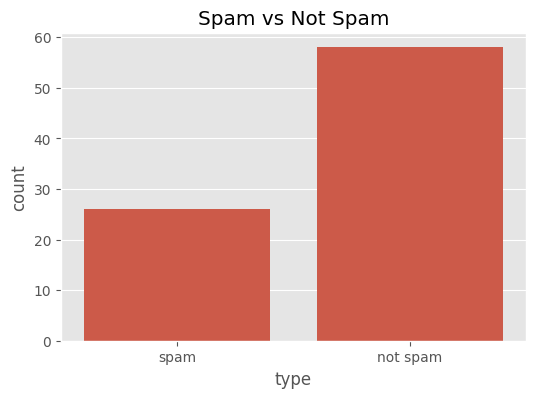

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Spam vs Not Spam")

plt.show()

In [11]:
df["email_length"] = df["text"].astype(str).apply(len)

df["email_length"].describe()

count      84.000000
mean      845.690476
std       989.806151
min        19.000000
25%       312.750000
50%       568.000000
75%       941.000000
max      6079.000000
Name: email_length, dtype: float64

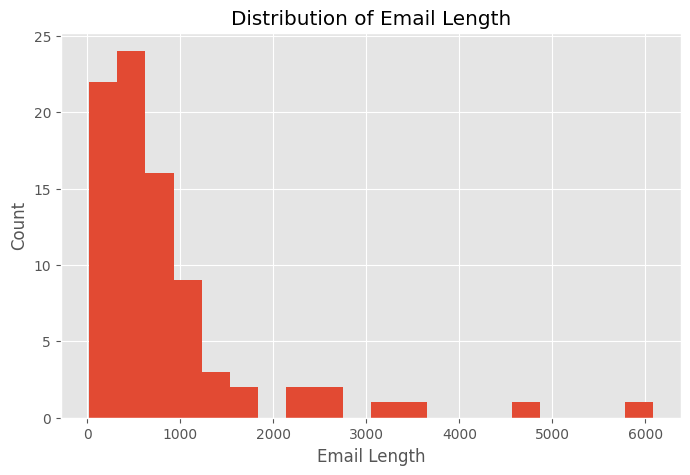

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["email_length"], bins=20)

plt.xlabel("Email Length")

plt.ylabel("Count")

plt.title("Distribution of Email Length")

plt.show()

In [13]:
print("Spam Email:\n")
print(df[df["type"]=="spam"]["text"].iloc[0])

print("\n\n----------------------\n")

print("Normal Email:\n")
print(df[df["type"]!="spam"]["text"].iloc[0])

Spam Email:

Hi James,

Have you claim your complimentary gift yet?

I've compiled in here a special astrology gift that predicts everything about you in the future?

This is your enabler to take the correct actions now.

>> Click here to claim your copy now >>

Claim yours now, and thank me later.


Love,
Heather


----------------------

Normal Email:


alt_text
Congratulations, you just earned
500


You completed the following offer:

View Points History
To stop recieving notifications when you earn points, please visit your profile and click "Preferences" to change your setting.

Room 1203, 12th Floor, Tower 3

China Hong Kong City, 33 Canton Road

Tsim Sha Tsui, Kowloon, Hong Kong

Unsubscribe


In [14]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (83, 4)


In [15]:
df["type"].value_counts()

type
not spam    57
spam        26
Name: count, dtype: int64

In [16]:
df.to_csv("../data/processed/email_spam_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


FINAL DATASET  EDA 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("X:/AI-SPAM-PHISHING-DETECTOR/data/processed/final_dataset.csv",keep_default_na=False)

df.head()

,title,text,type
0,?? the secrets to SUCCESS,"Hi James,\n\nHave you claim your complimentary...",spam
1,?? You Earned 500 GCLoot Points,"\nalt_text\nCongratulations, you just earned\n...",not spam
2,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420!\n ...",not spam
3,[The Virtual Reward Center] Re: ** Clarifications,"Hello,\n \nThank you for contacting the Virtua...",not spam
4,"10-1 MLB Expert Inside, Plus Everything You Ne...","Hey Prachanda Rawal,\n\nToday's newsletter is ...",spam


In [6]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("Dataset Information")
print("="*50)

df.info()

Dataset Shape
(5851, 3)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5851 entries, 0 to 5850
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   5851 non-null   object
 1   text    5851 non-null   object
 2   type    5851 non-null   object
dtypes: object(3)
memory usage: 137.3+ KB


In [7]:
print(df.isnull().sum())

title    0
text     0
type     0
dtype: int64


In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [9]:
df["type"].value_counts()

type
not spam    4425
spam        1426
Name: count, dtype: int64

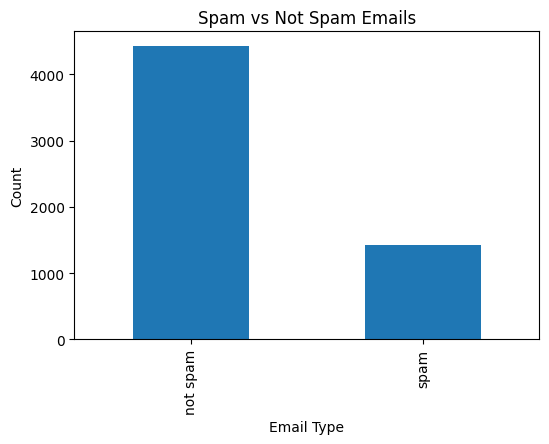

In [10]:
plt.figure(figsize=(6,4))

df["type"].value_counts().plot(kind="bar")

plt.title("Spam vs Not Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()

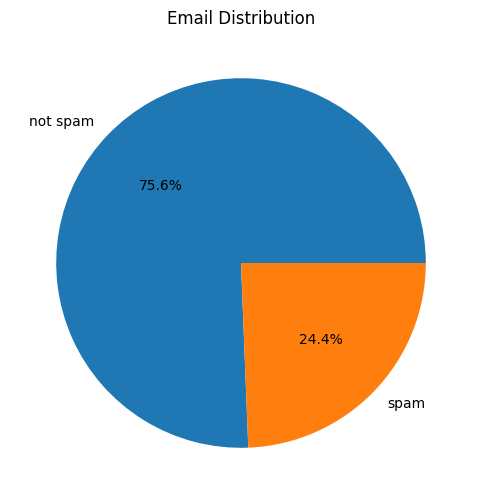

In [11]:
plt.figure(figsize=(6,6))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Email Distribution")

plt.show()

In [12]:
df["text_length"] = df["text"].apply(len)

df["text_length"].describe()

count      5851.000000
mean       1854.719193
std        4995.225613
min           1.000000
25%         534.000000
50%         970.000000
75%        1681.000000
max      194978.000000
Name: text_length, dtype: float64

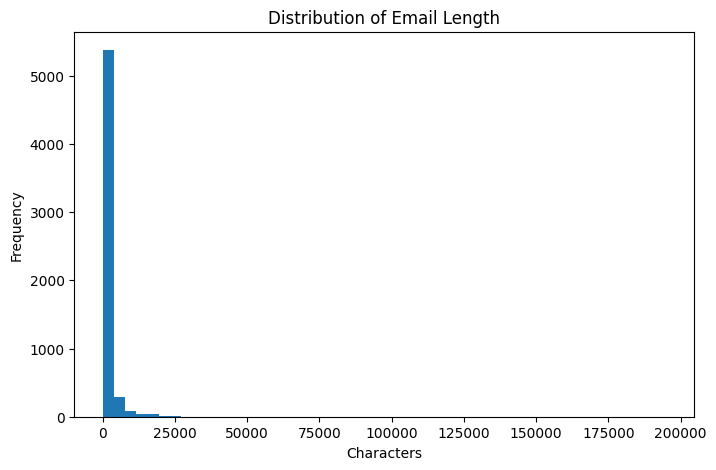

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["text_length"], bins=50)

plt.title("Distribution of Email Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

ADVANCED FINAL DATASET EDA

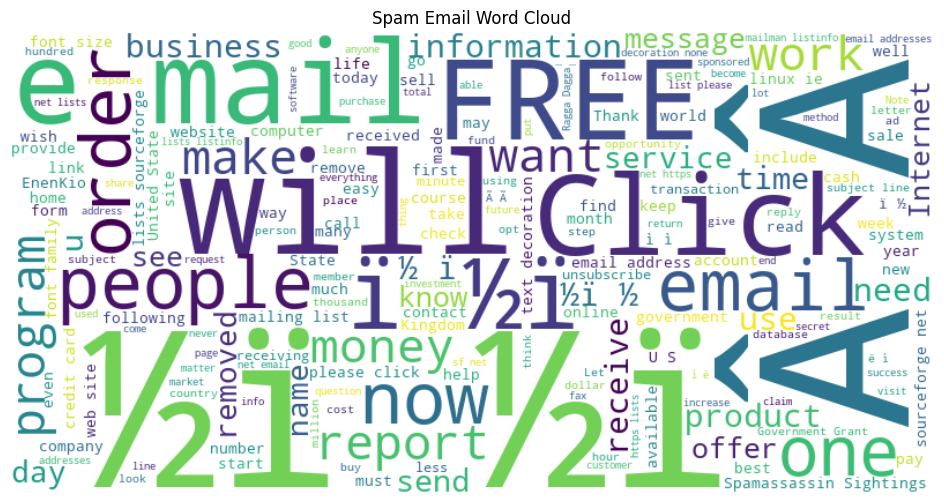

In [15]:
spam_text = " ".join(df[df["type"] == "spam"]["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Spam Email Word Cloud")
plt.show()

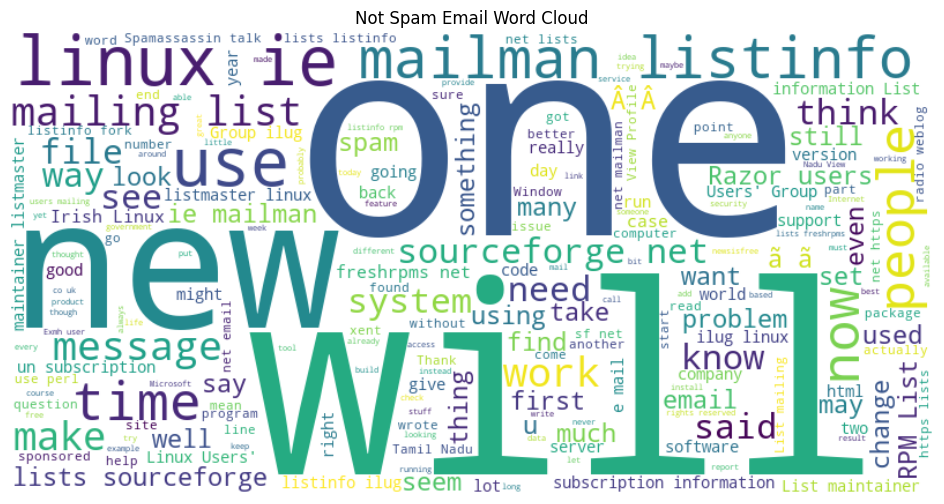

In [16]:
ham_text = " ".join(df[df["type"] == "not spam"]["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Not Spam Email Word Cloud")
plt.show()

In [17]:
from collections import Counter

all_words = " ".join(df["text"]).lower().split()

common_words = Counter(all_words).most_common(20)

common_df = pd.DataFrame(common_words, columns=["Word","Count"])

common_df

,Word,Count
0,the,59579
1,to,40403
2,and,30939
3,>,30115
4,of,29822
5,a,28405
6,in,19191
7,is,17265
8,for,16854
9,you,16578


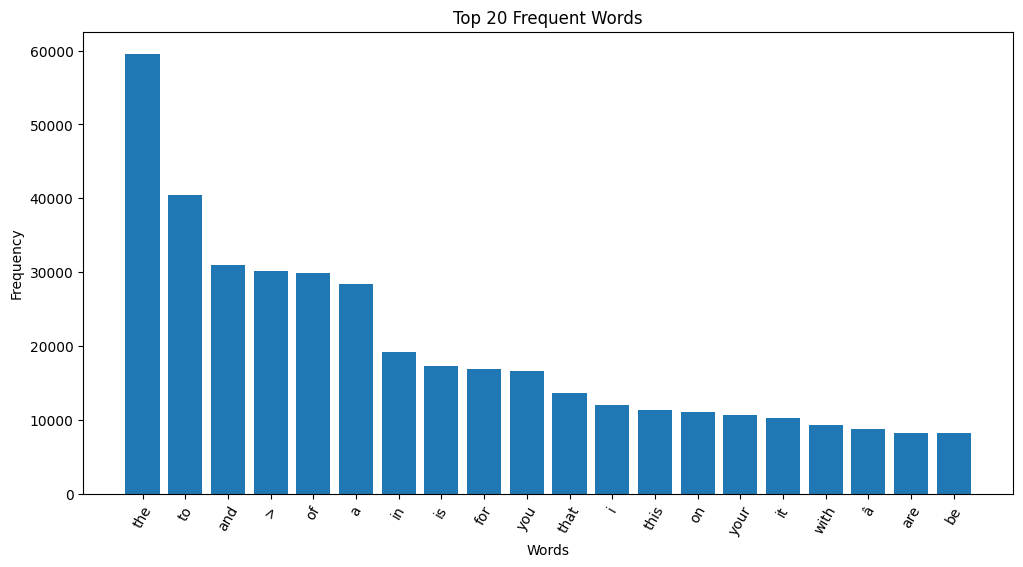

In [18]:
plt.figure(figsize=(12,6))

plt.bar(common_df["Word"], common_df["Count"])

plt.xticks(rotation=60)

plt.title("Top 20 Frequent Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

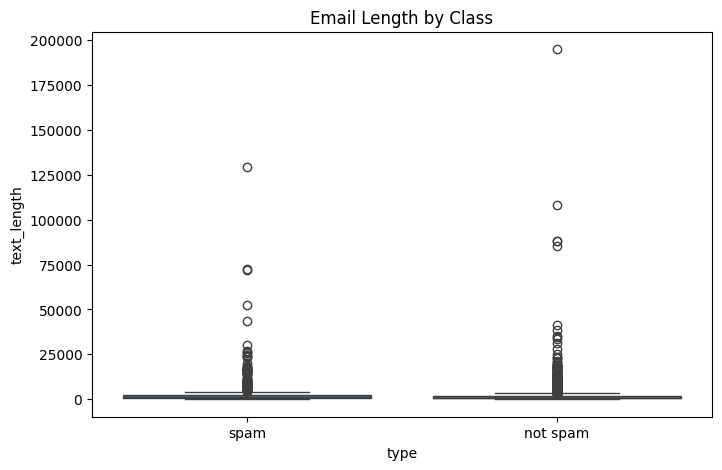

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="type",
    y="text_length",
    data=df
)

plt.title("Email Length by Class")

plt.show()

In [20]:
df.groupby("type")["text_length"].mean()

type
not spam    1699.448588
spam        2336.537167
Name: text_length, dtype: float64

In [21]:
df.describe(include="all")

,title,text,type,text_length
count,5851,5851,5851,5851.000000
unique,447,5775,2,NaN
top,,"Hi KASI, Thanks for using Amazon Pay Balance. ...",not spam,NaN
freq,5293,26,4425,NaN
mean,NaN,NaN,NaN,1854.719193
std,NaN,NaN,NaN,4995.225613
min,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,534.000000
50%,NaN,NaN,NaN,970.000000
75%,NaN,NaN,NaN,1681.000000


## Key Observations

- The dataset contains **5,851** email records.
- There are **3 features**: title, text, and type.
- No missing values are present after preprocessing.
- The dataset is moderately imbalanced:
  - Not Spam: 4,425
  - Spam: 1,426
- Spam emails contain words related to promotions, offers, money, and urgency.
- Legitimate emails contain conversational and informational words.
- Email lengths vary widely, making text preprocessing important before model training.